In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

#import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Feb 28 20:09:16 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P0              45W / 400W |      2MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [ ]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/TX_DATA

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/My Drive/TX_DATA


# Reading Data and Data Functions

In [ ]:
dfs = {}
for index in range(0, 6):
  df = pd.read_csv('Station' + str(index + 1) + '_simulated_cleaned_merged_data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
  dfs['Station' + str(index + 1)] = df
  df.index = pd.to_datetime(df.index)

In [ ]:
def engineer_data(dfs):
    day = 24 * 60 * 60
    year = 365.2425 * day
    for station, df in dfs.items():
        wv = df.pop('Windspeed')
        timestamp_s = (df.index).map(pd.Timestamp.timestamp)
        lat = df.pop('Latitude')
        lon = df.pop('Longitude')
        wd_rad = df.pop('Winddirection') * np.pi / 180
        df['Wx'] = wv * np.cos(wd_rad)
        df['Wy'] = wv * np.sin(wd_rad)
        df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
        df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
        df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
        df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
        df["x_cord"] = np.cos(lat) * np.cos(lon)
        df["y_cord"] = np.sin(lat) * np.cos(lon)
        df["z_cord"] = np.sin(lon)
        dfs[station] = df

In [ ]:
def scale_data(dfs):
    for station, df in dfs.items():
        cur_df = df.copy()
        d_sin = cur_df.pop("Day sin")
        d_cos = cur_df.pop("Day cos")
        y_sin = cur_df.pop("Year sin")
        y_cos = cur_df.pop("Year cos")
        x = cur_df.pop("x_cord")
        y = cur_df.pop("y_cord")
        z = cur_df.pop("z_cord")
        scaler = MinMaxScaler()
        scaled_df = pd.DataFrame(data=scaler.fit_transform(cur_df), columns=cur_df.columns, index=cur_df.index)
        scaled_df["Day sin"] = d_sin.values
        scaled_df["Day cos"] = d_cos.values
        scaled_df["Year sin"] = y_sin.values
        scaled_df["Year cos"] = y_cos.values
        scaled_df["x_cord"] = x.values
        scaled_df["y_cord"] = y.values
        scaled_df["z_cord"] = z.values
        dfs[station] = scaled_df

In [ ]:
  engineer_data(dfs)
  scale_data(dfs)

# Batches

In [ ]:
#Definitions
TARGET_COL = "SWC_5"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24*7
SHIFT_AMT = 10
PAT = 3
MAX_EPOCHS = 25

In [ ]:
def split(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  print(df.columns)
  target_idx = df.columns.get_loc(target_col)
  train_set = df[ : int(len(df) * train_split)].values
  val_set = df[int(len(df) * train_split) : int(len(df) * (train_split + val_split))].values
  test_set = df[int(len(df) * (train_split + val_split)) :].values
  return (train_set, val_set, test_set, target_idx)

In [ ]:
def generate_windows(data, window_size=24, shift=24, target_idx=0):
    labels = data[:, target_idx]

    X = []
    y = []
    for i in range(len(data) - window_size - shift):
        # get window based on input width
        window = data[i : i + window_size]

        # keep track of label associated with current window
        window_label = labels[i + window_size + shift]

        X.append(window)
        y.append(window_label)

    # in new dataset, each element is a data window, and window label is single value
    return np.array(X), np.array(y)


# given data and its labels, divide the data into batches of size batch_size
def generate_batches(X, y, batch_size=32):
    # divides data into batches, drops any remainder batches smaller than specified batch size.
    # allows models to run with any batch size
    tf_dataset = tf.data.Dataset.from_tensor_slices((X, y))
    tf_dataset = tf_dataset.repeat().batch(batch_size=batch_size, drop_remainder=True)

    # tf_dataset repeats indefinitely, need to compute number of step updates to complete 1 epoch
    steps_per_epoch = len(X) // batch_size

    return (tf_dataset, steps_per_epoch)


In [ ]:
def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split(df)


    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

In [ ]:
cur_df = dfs["Station1"]

BATCH_SIZE = 128
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(cur_df)

# divide each dataset into batched version to feed to models
train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)

Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Ppt.1', 'Tair', 'RH', 'Srad', 'Wx', 'Wy', 'Day sin', 'Day cos',
       'Year sin', 'Year cos', 'x_cord', 'y_cord', 'z_cord'],
      dtype='object')


# Modeling

In [ ]:
def compile_and_fit(model, data, steps_per_epoch, val_data, val_steps, model_name='model/', patience=3, max_epochs=MAX_EPOCHS, batch_size=32):
    # stop running epochs if the loss stops improving for patience number of epochs
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, mode='min')

    # store the best model on disk to be loaded later without having to re-fit
    # allows you to load models from disc
    ckpt = tf.keras.callbacks.ModelCheckpoint(model_name, save_best_only=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError()])

    history = model.fit(data,
                        epochs=max_epochs,
                        callbacks=[ckpt, early_stopping],
                        validation_data=val_data,
                        validation_steps=val_steps,
                        shuffle=False,
                        batch_size=batch_size,
                        steps_per_epoch = steps_per_epoch)

    return history

In [ ]:
preds = {}

def plot_single_pred(model, name, dataset, data_steps, y, batch_size=32):
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)
    preds[name] = forecast
    if len(forecast.shape) == 3:
        print("asd")
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:
        forecast = forecast[:, 0]

    plt.figure(figsize=(10, 6))
    plot_data = {"Predictions": forecast, "Actual": y}

    plt.plot(plot_data["Actual"])
    plt.plot(plot_data["Predictions"])

    plt.legend(("Actual", "Predictions"))

    return plot_data

In [ ]:
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [ ]:
bi_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh'),
])

In [ ]:
loss_by_epoch = {}
val_performance = {}
performance = {}

In [ ]:
history = compile_and_fit(bi_lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTM", patience=PAT)
loss_by_epoch["biLSTM"] = history.history
val_performance["biLSTM"] = bi_lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTM"] = bi_lstm_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25
315/315 [==============================] - 52s 134ms/step - loss: 0.0235 - mean_absolute_error: 0.1161 - mean_squared_error: 0.0235 - val_loss: 0.0308 - val_mean_absolute_error: 0.1255 - val_mean_squared_error: 0.0308
Epoch 2/25
315/315 [==============================] - 12s 39ms/step - loss: 0.0116 - mean_absolute_error: 0.0788 - mean_squared_error: 0.0116 - val_loss: 0.1194 - val_mean_absolute_error: 0.3021 - val_mean_squared_error: 0.1194
Epoch 3/25
315/315 [==============================] - 12s 39ms/step - loss: 0.0124 - mean_absolute_error: 0.0798 - mean_squared_error: 0.0124 - val_loss: 0.0521 - val_mean_absolute_error: 0.1707 - val_mean_squared_error: 0.0521
Epoch 4/25
89/89 [==============================] - 1s 15ms/step - loss: 0.0401 - mean_absolute_error: 0.1707 - mean_squared_error: 0.0401


In [ ]:
performance["biLSTM"][1]

0.14155852794647217

In [ ]:
history = compile_and_fit(lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="LSTM", patience=PAT)
loss_by_epoch["LSTM"] = history.history
val_performance["LSTM"] = lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["LSTM"] = lstm_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25
315/315 [==============================] - 22s 53ms/step - loss: 0.0224 - mean_absolute_error: 0.1148 - mean_squared_error: 0.0224 - val_loss: 0.0758 - val_mean_absolute_error: 0.2316 - val_mean_squared_error: 0.0758
Epoch 2/25
315/315 [==============================] - 15s 46ms/step - loss: 0.0139 - mean_absolute_error: 0.0827 - mean_squared_error: 0.0139 - val_loss: 0.0575 - val_mean_absolute_error: 0.1940 - val_mean_squared_error: 0.0575
Epoch 3/25
315/315 [==============================] - 7s 22ms/step - loss: 0.0105 - mean_absolute_error: 0.0692 - mean_squared_error: 0.0105 - val_loss: 0.0824 - val_mean_absolute_error: 0.2361 - val_mean_squared_error: 0.0824
Epoch 4/25
315/315 [==============================] - 15s 49ms/step - loss: 0.0090 - mean_absolute_error: 0.0588 - mean_squared_error: 0.0090 - val_loss: 0.0122 - val_mean_absolute_error: 0.0753 - val_mean_squared_error: 0.0122
Epoch 5/25
315/315 [==============================] - 15s 48ms/step - loss: 0.0063 - mean

In [ ]:
performance["LSTM"][1]

0.15401583909988403

43/43 [==============================] - 3s 16ms/step


{'Predictions': array([0.72322243, 0.7246642 , 0.72675186, ..., 0.27656928, 0.2799168 ,
        0.28132346], dtype=float32),
 'Actual': array([0.5037594 , 0.5037594 , 0.5       , ..., 0.19924812, 0.19924812,
        0.19548872])}

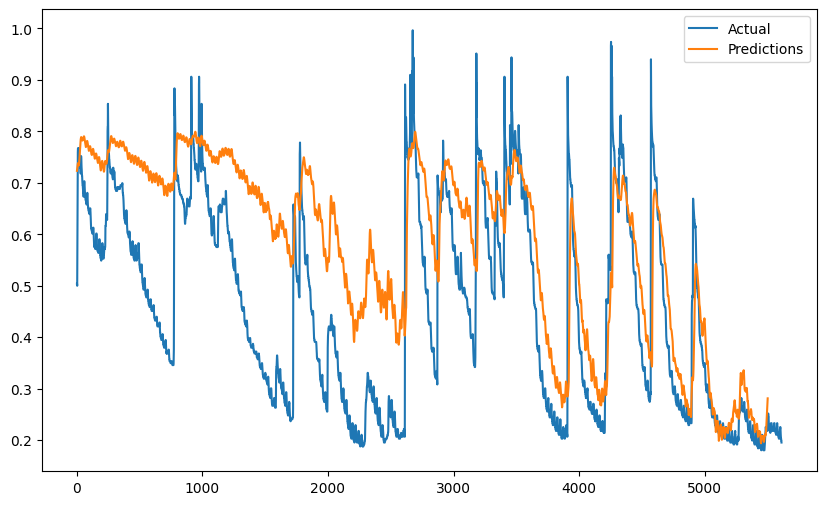

In [ ]:
plot_single_pred(bi_lstm_model,'BiLSTM', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

43/43 [==============================] - 1s 9ms/step


{'Predictions': array([0.8099483 , 0.8105949 , 0.8114959 , ..., 0.37139228, 0.38184705,
        0.39110506], dtype=float32),
 'Actual': array([0.5037594 , 0.5037594 , 0.5       , ..., 0.19924812, 0.19924812,
        0.19548872])}

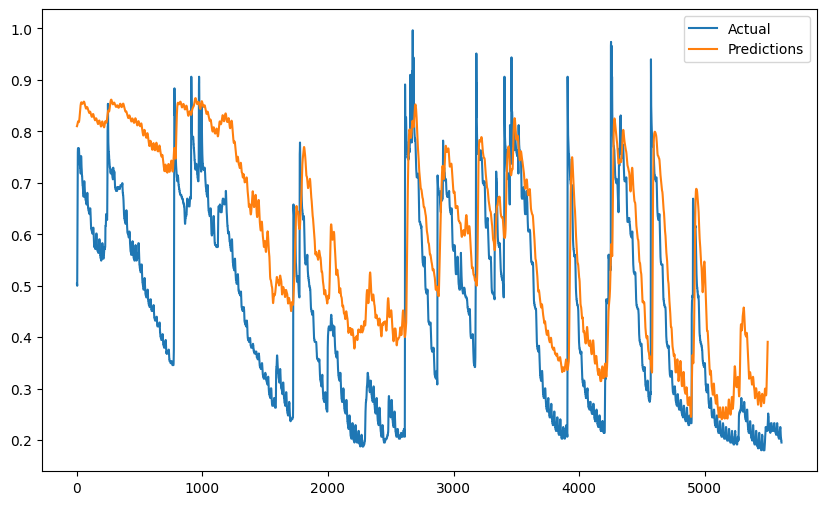

In [ ]:
plot_single_pred(lstm_model,'LSTM', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

#Feed Back Models

In [ ]:
class BiFeedBack(tf.keras.Model):
    def __init__(self, units, out_steps, num_features):
        super().__init__()
        self.out_steps = out_steps
        self.units = units
        # Use a Bidirectional LSTM layer
        self.bidirectional_lstm = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units, return_sequences=True, return_state=True))
        self.lstm_cell = tf.keras.layers.LSTMCell(units * 2)  # *2 because of concatenation of forward and backward states
        self.dense = tf.keras.layers.Dense(num_features)

    def call(self, inputs, training=None):
        predictions = []

        # Process the input sequence with the bidirectional LSTM.
        x, forward_h, forward_c, backward_h, backward_c = self.bidirectional_lstm(inputs)

        # Concatenate the forward and backward states
        state = [tf.keras.layers.concatenate([forward_h, backward_h]),
                 tf.keras.layers.concatenate([forward_c, backward_c])]

        # Initialize the first input of the generative process with the last output of the bidirectional LSTM
        prediction = self.dense(x[:, -1, :])

        # Insert the first prediction.
        predictions.append(prediction)

        # Run the rest of the prediction steps.
        for n in range(1, self.out_steps):
            x, state = self.lstm_cell(prediction, states=state, training=training)
            prediction = self.dense(x)
            predictions.append(prediction)

        predictions = tf.stack(predictions)
        predictions = tf.transpose(predictions, [1, 0, 2])
        return predictions


In [ ]:
class FeedBack(tf.keras.Model):
    def __init__(self, units, out_steps, num_features):
        super().__init__()
        self.out_steps = out_steps
        self.units = units
        self.lstm_cell = tf.keras.layers.LSTMCell(units)
        self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
        self.dense = tf.keras.layers.Dense(num_features)

    def call(self, inputs, training=None):
        # Use a TensorArray to capture dynamically unrolled outputs.
        predictions = []

        # Initialize the LSTM state.
        x, *state = self.lstm_rnn(inputs)

        # This is the prediction for the first time step
        prediction = self.dense(x)

        # Insert the first prediction.
        predictions.append(prediction)

        # Run the rest of the prediction steps.
        for n in range(1, self.out_steps):
            # Use the last prediction as input.
            x = prediction
            # Execute one lstm step.
            x, state = self.lstm_cell(x, states=state,
                              training=training)
            # Convert the lstm output to a prediction.
            prediction = self.dense(x)
            # Add the prediction to the output.
            predictions.append(prediction)

        # predictions.shape => (time, batch, features)
        predictions = tf.stack(predictions)
        # predictions.shape => (batch, time, features)
        predictions = tf.transpose(predictions, [1, 0, 2])
        return predictions

In [ ]:
feedback_model = FeedBack(units=128, out_steps=1, num_features=1)

history = compile_and_fit(feedback_model, train_dataset, train_steps, val_dataset, val_steps, model_name="Feedback", patience = 5)
loss_by_epoch["Feedback"] = history.history
val_performance["Feedback"] = feedback_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["Feedback"] = feedback_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25
315/315 [==============================] - 25s 75ms/step - loss: 0.0193 - mean_absolute_error: 0.1031 - mean_squared_error: 0.0193 - val_loss: 0.0660 - val_mean_absolute_error: 0.2208 - val_mean_squared_error: 0.0660
Epoch 2/25
315/315 [==============================] - 24s 76ms/step - loss: 0.0223 - mean_absolute_error: 0.1067 - mean_squared_error: 0.0223 - val_loss: 0.0621 - val_mean_absolute_error: 0.2073 - val_mean_squared_error: 0.0621
Epoch 3/25
315/315 [==============================] - 23s 72ms/step - loss: 0.0257 - mean_absolute_error: 0.1235 - mean_squared_error: 0.0257 - val_loss: 0.0667 - val_mean_absolute_error: 0.2177 - val_mean_squared_error: 0.0667
Epoch 4/25
315/315 [==============================] - 24s 77ms/step - loss: 0.0149 - mean_absolute_error: 0.0887 - mean_squared_error: 0.0149 - val_loss: 0.0195 - val_mean_absolute_error: 0.0983 - val_mean_squared_error: 0.0195
Epoch 5/25
315/315 [==============================] - 24s 76ms/step - loss: 0.0124 - mea

In [ ]:
performance["Feedback"][1]

0.10300600528717041

In [ ]:
bi_feedback_model = BiFeedBack(units=128, out_steps=1, num_features=1)

history = compile_and_fit(bi_feedback_model, train_dataset, train_steps, val_dataset, val_steps, model_name="BiFeedback", patience = 5)
loss_by_epoch["BiFeedback"] = history.history
val_performance["BiFeedback"] = bi_feedback_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["BiFeedback"] = bi_feedback_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25
315/315 [==============================] - 18s 47ms/step - loss: 0.0237 - mean_absolute_error: 0.1191 - mean_squared_error: 0.0237 - val_loss: 0.0614 - val_mean_absolute_error: 0.1913 - val_mean_squared_error: 0.0614
Epoch 2/25
315/315 [==============================] - 14s 44ms/step - loss: 0.0236 - mean_absolute_error: 0.1176 - mean_squared_error: 0.0236 - val_loss: 0.0366 - val_mean_absolute_error: 0.1470 - val_mean_squared_error: 0.0366
Epoch 3/25
315/315 [==============================] - 15s 47ms/step - loss: 0.0170 - mean_absolute_error: 0.0969 - mean_squared_error: 0.0170 - val_loss: 0.0137 - val_mean_absolute_error: 0.0868 - val_mean_squared_error: 0.0137
Epoch 4/25
315/315 [==============================] - 5s 16ms/step - loss: 0.0138 - mean_absolute_error: 0.0803 - mean_squared_error: 0.0138 - val_loss: 0.0223 - val_mean_absolute_error: 0.1113 - val_mean_squared_error: 0.0223
Epoch 5/25
315/315 [==============================] - 5s 16ms/step - loss: 0.0139 - mean_

In [ ]:
performance["BiFeedback"][1]

0.11045911908149719

43/43 [==============================] - 1s 26ms/step
asd


{'Predictions': array([0.4185202 , 0.41948155, 0.4180815 , ..., 0.21502426, 0.21549739,
        0.21734113], dtype=float32),
 'Actual': array([0.5037594 , 0.5037594 , 0.5       , ..., 0.19924812, 0.19924812,
        0.19548872])}

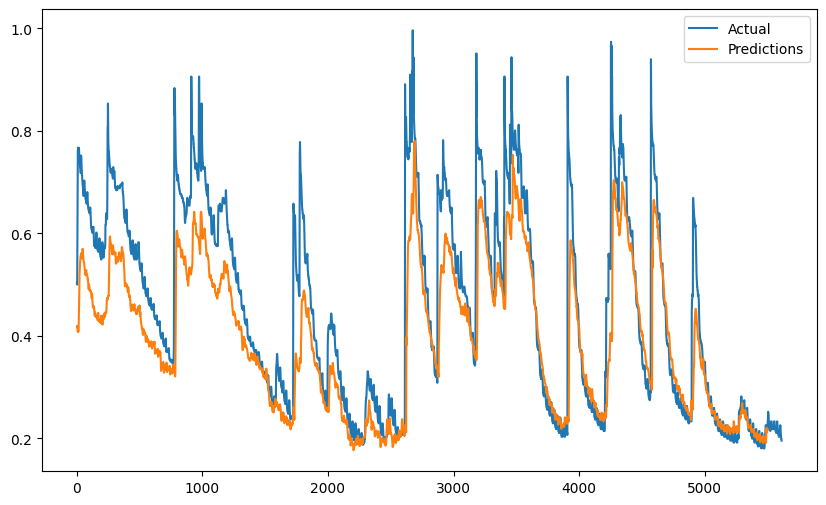

In [ ]:
plot_single_pred(feedback_model, 'Feedback', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

43/43 [==============================] - 1s 7ms/step
asd


{'Predictions': array([0.3723004 , 0.37366724, 0.37398538, ..., 0.18878518, 0.18772103,
        0.1861185 ], dtype=float32),
 'Actual': array([0.5037594 , 0.5037594 , 0.5       , ..., 0.19924812, 0.19924812,
        0.19548872])}

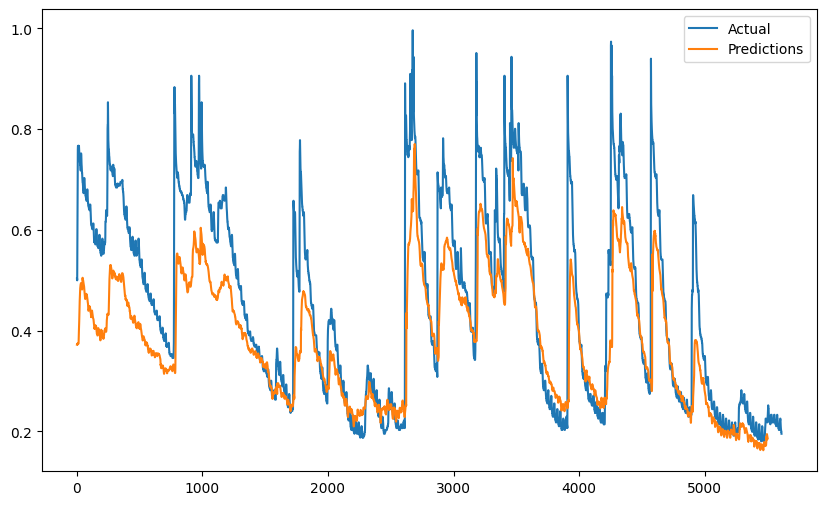

In [ ]:
plot_single_pred(bi_feedback_model,'BiFeedback', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

In [ ]:
lstm_pred = preds["LSTM"][:, 0]
bi_lstm_pred = preds["BiLSTM"][:, 0]
feedback_pred = preds["Feedback"][:, 0, 0]
bi_feedback_pred = preds["BiFeedback"][:, 0, 0]

In [ ]:
print(len(lstm_pred))
print(len(feedback_pred))
print(len(bi_lstm_pred))
print(len(bi_feedback_pred))


5504
5504
5504
5504


In [ ]:
def create_error_table(y):
  data = {
    "LSTM": [mean_squared_error(y, lstm_pred),mean_absolute_error(y, lstm_pred),mean_squared_error(y, lstm_pred, squared = False), mean_absolute_percentage_error(y, lstm_pred)],
    "BiLSTM": [mean_squared_error(y, bi_lstm_pred ),mean_absolute_error(y,bi_lstm_pred ),mean_squared_error(y, bi_lstm_pred , squared = False), mean_absolute_percentage_error(y, bi_lstm_pred )],
    "Feedback": [mean_squared_error(y, feedback_pred),mean_absolute_error(y,feedback_pred),mean_squared_error(y,feedback_pred, squared = False), mean_absolute_percentage_error(y, feedback_pred)],
    "BiFeedback": [mean_squared_error(y, bi_feedback_pred),mean_absolute_error(y, bi_feedback_pred),mean_squared_error(y,bi_feedback_pred, squared = False), mean_absolute_percentage_error(y, bi_feedback_pred)],
  }
  res = pd.DataFrame.from_dict(data, orient='index')
  res.columns = ["MSE", "MAE", "RMSE", "MAPE"]
  return res

In [ ]:
y = y_test[len(y_test)-len(lstm_pred):]

In [ ]:
create_error_table(y)

,MSE,MAE,RMSE,MAPE
LSTM,0.062913,0.222441,0.250825,0.606432
BiLSTM,0.057317,0.204665,0.239409,0.571725
Feedback,0.039935,0.144539,0.199837,0.306241
BiFeedback,0.038275,0.144004,0.195640,0.300817
